# CAFA-6 Evaluation Results Analysis

Notebook này phân tích trực tiếp các folder kết quả evaluator đã download về local:

```text
cafa6_high_performance_artifacts/cafa6_eval_results/        # kết quả ensemble ban đầu
cafa6_high_performance_artifacts/cafa6_submodels_results/   # kết quả từng submodel + ensemble
```

Notebook chỉ hiển thị bảng và biểu đồ trong output cell, không ghi thêm file phân tích.

In [30]:
# =============================
# 0. Setup and load evaluator result folders
# =============================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RESULT_SETS = {
    "ensemble_original": Path("../cafa6_high_performance_artifacts/cafa6_eval_results"),
    "submodels": Path("../cafa6_high_performance_artifacts/cafa6_submodels_results"),
}

missing = [name for name, path in RESULT_SETS.items() if not (path / "evaluation_all.tsv").exists()]
if missing:
    raise FileNotFoundError(f"Missing result sets: {missing}")

print("[RESULT SETS]")
for name, path in RESULT_SETS.items():
    print(f"\n{name}: {path.resolve()}")
    for p in sorted(path.glob("*.tsv")):
        print(f"  - {p.name} ({p.stat().st_size / 1024:.1f} KB)")


def dedupe_columns(columns):
    seen = {}
    out = []
    for col in [str(c).strip() for c in columns]:
        if col not in seen:
            seen[col] = 0
            out.append(col)
        else:
            seen[col] += 1
            out.append(f"{col}__dup{seen[col]}")
    return out


def read_tsv(path):
    df = pd.read_csv(path, sep="\t")
    df.columns = dedupe_columns(df.columns)
    return df

all_tables = []
best_tables = []
for result_name, result_dir in RESULT_SETS.items():
    df = read_tsv(result_dir / "evaluation_all.tsv")
    df["_result_set"] = result_name
    all_tables.append(df)
    for p in sorted(result_dir.glob("evaluation_best_*.tsv")):
        metric = p.stem.replace("evaluation_best_", "")
        b = read_tsv(p)
        b["_result_set"] = result_name
        b["_best_metric_file"] = metric
        best_tables.append(b)

eval_all_raw = pd.concat(all_tables, ignore_index=True)
best_raw = pd.concat(best_tables, ignore_index=True)

print(f"[LOAD] eval_all_raw={eval_all_raw.shape}")
print(f"[LOAD] best_raw={best_raw.shape}")
display(eval_all_raw.head())
display(best_raw.head())

[RESULT SETS]

ensemble_original: /Users/duongminhquan/Documents/BioInformatics/cafa6_high_performance_artifacts/cafa6_eval_results
  - evaluation_all.tsv (41.9 KB)
  - evaluation_best_f.tsv (0.8 KB)
  - evaluation_best_f_micro.tsv (0.8 KB)
  - evaluation_best_f_micro_w.tsv (0.8 KB)
  - evaluation_best_f_w.tsv (0.8 KB)
  - evaluation_best_s.tsv (0.8 KB)

submodels: /Users/duongminhquan/Documents/BioInformatics/cafa6_high_performance_artifacts/cafa6_submodels_results
  - evaluation_all.tsv (167.9 KB)
  - evaluation_best_f.tsv (2.8 KB)
  - evaluation_best_f_micro.tsv (2.8 KB)
  - evaluation_best_f_micro_w.tsv (2.8 KB)
  - evaluation_best_f_w.tsv (2.8 KB)
  - evaluation_best_s.tsv (2.7 KB)
[LOAD] eval_all_raw=(1000, 32)
[LOAD] best_raw=(75, 34)


,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro,n_w,tp_w,fp_w,fn_w,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w,_result_set
0,ensemble.tsv,biological_process,0.01,7367.0,9.037,1113.546,0.388,0.008,0.962,1.0,1113.546,0.388,0.016,1113.547,0.008,0.959,0.016,7299.0,9.389,1242.057,0.462,0.007,0.964,1.0,1242.057,0.462,0.015,1242.057,0.008,0.953,0.015,ensemble_original
1,ensemble.tsv,biological_process,0.02,7367.0,8.935,970.070,0.491,0.009,0.947,1.0,970.070,0.491,0.018,970.070,0.009,0.948,0.018,7299.0,9.266,1078.485,0.584,0.009,0.950,1.0,1078.485,0.584,0.017,1078.485,0.009,0.941,0.017,ensemble_original
2,ensemble.tsv,biological_process,0.03,7367.0,8.533,694.242,0.893,0.013,0.893,1.0,694.242,0.893,0.025,694.242,0.012,0.905,0.024,7299.0,8.783,754.320,1.067,0.012,0.900,1.0,754.320,1.067,0.024,754.320,0.012,0.892,0.023,ensemble_original
3,ensemble.tsv,biological_process,0.04,7367.0,7.926,475.972,1.499,0.018,0.825,1.0,475.972,1.499,0.035,475.974,0.016,0.841,0.032,7299.0,8.061,505.645,1.790,0.018,0.833,1.0,505.645,1.790,0.034,505.648,0.016,0.818,0.031,ensemble_original
4,ensemble.tsv,biological_process,0.05,7367.0,7.247,333.355,2.179,0.024,0.751,1.0,333.355,2.179,0.047,333.362,0.021,0.769,0.041,7299.0,7.292,348.929,2.558,0.024,0.757,1.0,348.929,2.558,0.046,348.939,0.020,0.740,0.040,ensemble_original


,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro,n_w,tp_w,fp_w,fn_w,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w,cov_max,_result_set,_best_metric_file
0,ensemble.tsv,biological_process,0.16,5514.0,1.867,14.144,7.558,0.139,0.201,0.748,14.144,7.558,0.164,16.037,0.117,0.198,0.147,5484.0,1.579,13.259,8.271,0.130,0.189,0.751,13.259,8.271,0.154,15.627,0.106,0.160,0.128,1.0,ensemble_original,f
1,ensemble.tsv,cellular_component,0.31,8420.0,2.463,2.674,3.643,0.525,0.536,0.957,2.674,3.643,0.531,4.519,0.479,0.403,0.438,8420.0,2.336,3.522,5.418,0.470,0.481,0.957,3.522,5.418,0.476,6.462,0.399,0.301,0.343,1.0,ensemble_original,f
2,ensemble.tsv,molecular_function,0.28,7013.0,1.380,1.657,2.631,0.659,0.509,0.948,1.657,2.631,0.574,3.109,0.454,0.344,0.392,7013.0,0.917,1.664,5.106,0.636,0.436,0.948,1.664,5.106,0.517,5.370,0.355,0.152,0.213,1.0,ensemble_original,f
3,ensemble.tsv,biological_process,0.17,5165.0,1.624,10.914,7.802,0.152,0.177,0.701,10.914,7.802,0.164,13.416,0.130,0.172,0.148,5138.0,1.325,10.157,8.525,0.139,0.165,0.704,10.157,8.525,0.151,13.261,0.115,0.135,0.124,1.0,ensemble_original,f_micro
4,ensemble.tsv,cellular_component,0.29,8610.0,2.645,3.268,3.461,0.493,0.568,0.978,3.268,3.461,0.528,4.760,0.447,0.433,0.440,8610.0,2.536,4.380,5.219,0.434,0.512,0.978,4.380,5.219,0.470,6.814,0.367,0.327,0.346,1.0,ensemble_original,f_micro


In [31]:
# =============================
# 1. Normalize columns
# =============================
def find_col(df, candidates, contains=None):
    lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    if contains:
        for col in df.columns:
            lc = col.lower()
            if all(token.lower() in lc for token in contains):
                return col
    return None

method_col = find_col(eval_all_raw, ["filename", "file", "method", "model", "pred_file"], contains=["file"])
namespace_col = find_col(eval_all_raw, ["namespace", "ontology", "aspect", "ns"], contains=["namespace"])
threshold_col = find_col(eval_all_raw, ["threshold", "th", "tau", "cutoff"], contains=["th"])

f_col = find_col(eval_all_raw, ["f", "fmax", "f_max", "F", "Fmax"])
fw_col = find_col(eval_all_raw, ["f_w", "wf", "wF", "weighted_f", "weighted_fmax", "f_weighted"], contains=["f", "w"])
f_micro_col = find_col(eval_all_raw, ["f_micro", "micro_f", "micro_f1"], contains=["f", "micro"])
f_micro_w_col = find_col(eval_all_raw, ["f_micro_w", "micro_f_w", "weighted_micro_f"], contains=["f", "micro", "w"])
precision_col = find_col(eval_all_raw, ["precision", "pr", "p"], contains=["precision"])
recall_col = find_col(eval_all_raw, ["recall", "rc", "r"], contains=["recall"])
s_col = find_col(eval_all_raw, ["s", "smin", "s_min", "S", "Smin"])

def first_existing_unique(cols):
    seen = set()
    for col in cols:
        if col is None or col in seen:
            continue
        seen.add(col)
        if col in eval_all_raw.columns:
            return col
    return None

# Prefer exact non-duplicate evaluator columns over duplicate-renamed variants.
f_col = first_existing_unique([f_col])
fw_col = first_existing_unique([fw_col])
f_micro_col = first_existing_unique([f_micro_col])
f_micro_w_col = first_existing_unique([f_micro_w_col])
precision_col = first_existing_unique([precision_col])
recall_col = first_existing_unique([recall_col])
s_col = first_existing_unique([s_col])

print("[DETECTED COLUMNS]")
for name, col in {
    "method": method_col,
    "namespace": namespace_col,
    "threshold": threshold_col,
    "f": f_col,
    "f_w": fw_col,
    "f_micro": f_micro_col,
    "f_micro_w": f_micro_w_col,
    "precision": precision_col,
    "recall": recall_col,
    "s": s_col,
}.items():
    print(f"  {name:14s}: {col}")

eval_all = eval_all_raw.copy()
eval_all["_method"] = eval_all[method_col].astype(str).str.replace(".tsv", "", regex=False) if method_col else "method"
eval_all["_namespace"] = eval_all[namespace_col].astype(str) if namespace_col else "all"
eval_all["_threshold"] = pd.to_numeric(eval_all[threshold_col], errors="coerce") if threshold_col else np.nan

for col in [f_col, fw_col, f_micro_col, f_micro_w_col, precision_col, recall_col, s_col]:
    if col is not None and col in eval_all.columns:
        eval_all[col] = pd.to_numeric(eval_all[col], errors="coerce")

best = best_raw.copy()
if method_col and method_col in best.columns:
    best["_method"] = best[method_col].astype(str).str.replace(".tsv", "", regex=False)
else:
    b_method_col = find_col(best, ["filename", "file", "method", "model", "pred_file"], contains=["file"])
    best["_method"] = best[b_method_col].astype(str).str.replace(".tsv", "", regex=False) if b_method_col else "method"
if namespace_col and namespace_col in best.columns:
    best["_namespace"] = best[namespace_col].astype(str)
else:
    b_ns_col = find_col(best, ["namespace", "ontology", "aspect", "ns"], contains=["namespace"])
    best["_namespace"] = best[b_ns_col].astype(str) if b_ns_col else "all"

print("\nMethods by result set:")
for rs, g in eval_all.groupby("_result_set"):
    print(rs, sorted(g["_method"].unique().tolist()))
print("Namespaces:", sorted(eval_all["_namespace"].unique().tolist()))

[DETECTED COLUMNS]
  method        : filename
  namespace     : ns
  threshold     : tau
  f             : f
  f_w           : f_w
  f_micro       : f_micro
  f_micro_w     : f_micro_w
  precision     : pr
  recall        : rc
  s             : s

Methods by result set:
ensemble_original ['ensemble']
submodels ['bilstm_attention', 'ensemble', 'esm_mlp', 'protcnn']
Namespaces: ['biological_process', 'cellular_component', 'molecular_function']


In [32]:
# =============================
# 2. Show evaluator best files
# =============================
for (rs, metric), df in best.groupby(["_result_set", "_best_metric_file"]):
    print(f"\n=== {rs} | evaluation_best_{metric}.tsv | shape={df.shape} ===")
    display(df)


=== ensemble_original | evaluation_best_f.tsv | shape=(3, 36) ===


,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro,n_w,tp_w,fp_w,fn_w,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w,cov_max,_result_set,_best_metric_file,_method,_namespace
0,ensemble.tsv,biological_process,0.16,5514.0,1.867,14.144,7.558,0.139,0.201,0.748,14.144,7.558,0.164,16.037,0.117,0.198,0.147,5484.0,1.579,13.259,8.271,0.130,0.189,0.751,13.259,8.271,0.154,15.627,0.106,0.160,0.128,1.0,ensemble_original,f,ensemble,biological_process
1,ensemble.tsv,cellular_component,0.31,8420.0,2.463,2.674,3.643,0.525,0.536,0.957,2.674,3.643,0.531,4.519,0.479,0.403,0.438,8420.0,2.336,3.522,5.418,0.470,0.481,0.957,3.522,5.418,0.476,6.462,0.399,0.301,0.343,1.0,ensemble_original,f,ensemble,cellular_component
2,ensemble.tsv,molecular_function,0.28,7013.0,1.380,1.657,2.631,0.659,0.509,0.948,1.657,2.631,0.574,3.109,0.454,0.344,0.392,7013.0,0.917,1.664,5.106,0.636,0.436,0.948,1.664,5.106,0.517,5.370,0.355,0.152,0.213,1.0,ensemble_original,f,ensemble,molecular_function



=== ensemble_original | evaluation_best_f_micro.tsv | shape=(3, 36) ===


,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro,n_w,tp_w,fp_w,fn_w,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w,cov_max,_result_set,_best_metric_file,_method,_namespace
3,ensemble.tsv,biological_process,0.17,5165.0,1.624,10.914,7.802,0.152,0.177,0.701,10.914,7.802,0.164,13.416,0.130,0.172,0.148,5138.0,1.325,10.157,8.525,0.139,0.165,0.704,10.157,8.525,0.151,13.261,0.115,0.135,0.124,1.0,ensemble_original,f_micro,ensemble,biological_process
4,ensemble.tsv,cellular_component,0.29,8610.0,2.645,3.268,3.461,0.493,0.568,0.978,3.268,3.461,0.528,4.760,0.447,0.433,0.440,8610.0,2.536,4.380,5.219,0.434,0.512,0.978,4.380,5.219,0.470,6.814,0.367,0.327,0.346,1.0,ensemble_original,f_micro,ensemble,cellular_component
5,ensemble.tsv,molecular_function,0.28,7013.0,1.380,1.657,2.631,0.659,0.509,0.948,1.657,2.631,0.574,3.109,0.454,0.344,0.392,7013.0,0.917,1.664,5.106,0.636,0.436,0.948,1.664,5.106,0.517,5.370,0.355,0.152,0.213,1.0,ensemble_original,f_micro,ensemble,molecular_function



=== ensemble_original | evaluation_best_f_micro_w.tsv | shape=(3, 36) ===


...

,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro,n_w,tp_w,fp_w,fn_w,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w,cov_max,_result_set,_best_metric_file,_method,_namespace
39,bilstm_attention.tsv,biological_process,0.09,7360.0,2.066,32.999,7.360,0.066,0.249,0.999,32.999,7.360,0.104,33.809,0.059,0.219,0.093,7292.0,1.833,34.158,8.017,0.060,0.242,0.999,34.158,8.017,0.096,35.086,0.051,0.186,0.080,1.0,submodels,f_micro_w,bilstm_attention,biological_process
40,bilstm_attention.tsv,cellular_component,0.24,8800.0,2.432,4.611,3.674,0.378,0.533,1.000,4.611,3.674,0.442,5.895,0.345,0.398,0.370,8800.0,2.017,6.106,5.738,0.287,0.464,1.000,6.106,5.738,0.354,8.379,0.248,0.260,0.254,1.0,submodels,f_micro_w,bilstm_attention,cellular_component
41,bilstm_attention.tsv,molecular_function,0.16,7397.0,1.403,5.005,2.608,0.312,0.538,1.000,5.005,2.608,0.395,5.643,0.219,0.350,0.269,7397.0,1.125,7.802,4.898,0.207,0.478,1.000,7.802,4.898,0.289,9.212,0.126,0.187,0.150,1.0,submodels,f_micro_w,bilstm_attention,molecular_function
42,ensemble.tsv,biological_process,0.15,5848.0,2.154,18.324,7.272,0.126,0.229,0.794,18.324,7.272,0.162,19.714,0.105,0.229,0.144,5811.0,1.869,17.246,7.981,0.118,0.218,0.796,17.246,7.981,0.154,19.004,0.098,0.190,0.129,1.0,submodels,f_micro_w,ensemble,biological_process
43,ensemble.tsv,cellular_component,0.28,8665.0,2.735,3.613,3.371,0.477,0.582,0.985,3.613,3.371,0.525,4.941,0.431,0.448,0.439,8665.0,2.642,4.875,5.113,0.417,0.525,0.985,4.875,5.113,0.465,7.064,0.351,0.341,0.346,1.0,submodels,f_micro_w,ensemble,cellular_component
44,ensemble.tsv,molecular_function,0.22,7374.0,1.764,4.023,2.246,0.473,0.591,0.997,4.023,2.246,0.525,4.608,0.305,0.440,0.360,7374.0,1.521,5.337,4.502,0.418,0.524,0.997,5.337,4.502,0.465,6.982,0.222,0.253,0.236,1.0,submodels,f_micro_w,ensemble,molecular_function
45,esm_mlp.tsv,biological_process,0.21,5361.0,1.837,14.138,7.589,0.140,0.198,0.728,14.138,7.589,0.164,16.046,0.115,0.195,0.145,5329.0,1.568,13.564,8.282,0.131,0.188,0.730,13.564,8.282,0.154,15.893,0.104,0.159,0.126,1.0,submodels,f_micro_w,esm_mlp,biological_process
46,esm_mlp.tsv,cellular_component,0.35,8341.0,2.596,3.741,3.510,0.489,0.547,0.948,3.741,3.510,0.516,5.130,0.410,0.425,0.417,8341.0,2.576,5.369,5.178,0.432,0.494,0.948,5.369,5.178,0.461,7.459,0.324,0.332,0.328,1.0,submodels,f_micro_w,esm_mlp,cellular_component
47,esm_mlp.tsv,molecular_function,0.29,6791.0,1.654,3.773,2.356,0.488,0.539,0.918,3.773,2.356,0.512,4.448,0.305,0.413,0.351,6791.0,1.428,4.918,4.594,0.447,0.477,0.918,4.918,4.594,0.461,6.730,0.225,0.237,0.231,1.0,submodels,f_micro_w,esm_mlp,molecular_function
48,protcnn.tsv,biological_process,0.14,7367.0,1.572,26.481,7.854,0.069,0.166,1.000,26.481,7.854,0.098,27.621,0.056,0.167,0.084,7299.0,1.134,21.363,8.717,0.053,0.143,1.000,21.363,8.717,0.077,23.073,0.050,0.115,0.070,1.0,submodels,f_micro_w,protcnn,biological_process



=== submodels | evaluation_best_f_w.tsv | shape=(12, 36) ===


,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro,n_w,tp_w,fp_w,fn_w,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w,cov_max,_result_set,_best_metric_file,_method,_namespace
51,bilstm_attention.tsv,biological_process,0.12,5817.0,0.966,10.241,8.460,0.108,0.123,0.790,10.241,8.460,0.115,13.283,0.086,0.103,0.094,5759.0,0.690,10.701,9.161,0.114,0.107,0.789,10.701,9.161,0.110,14.086,0.061,0.070,0.065,1.0,submodels,f_w,bilstm_attention,biological_process
52,bilstm_attention.tsv,cellular_component,0.29,8495.0,2.121,3.129,3.985,0.430,0.475,0.965,3.129,3.985,0.451,5.067,0.404,0.347,0.374,8495.0,1.632,3.777,6.123,0.335,0.401,0.965,3.777,6.123,0.365,7.194,0.302,0.210,0.248,1.0,submodels,f_w,bilstm_attention,cellular_component
53,bilstm_attention.tsv,molecular_function,0.23,7138.0,0.909,1.320,3.101,0.657,0.428,0.965,1.320,3.101,0.518,3.370,0.408,0.227,0.291,7138.0,0.349,1.313,5.674,0.642,0.348,0.965,1.313,5.674,0.452,5.824,0.210,0.058,0.091,1.0,submodels,f_w,bilstm_attention,molecular_function
54,ensemble.tsv,biological_process,0.16,5514.0,1.867,14.144,7.558,0.139,0.201,0.748,14.144,7.558,0.164,16.037,0.117,0.198,0.147,5484.0,1.579,13.259,8.271,0.130,0.189,0.751,13.259,8.271,0.154,15.627,0.106,0.160,0.128,1.0,submodels,f_w,ensemble,biological_process
55,ensemble.tsv,cellular_component,0.32,8309.0,2.373,2.429,3.733,0.540,0.520,0.944,2.429,3.733,0.530,4.454,0.494,0.389,0.435,8309.0,2.242,3.162,5.513,0.489,0.465,0.944,3.162,5.513,0.477,6.355,0.415,0.289,0.341,1.0,submodels,f_w,ensemble,cellular_component
56,ensemble.tsv,molecular_function,0.28,7013.0,1.380,1.657,2.631,0.659,0.509,0.948,1.657,2.631,0.574,3.109,0.454,0.344,0.392,7013.0,0.917,1.664,5.106,0.636,0.436,0.948,1.664,5.106,0.517,5.370,0.355,0.152,0.213,1.0,submodels,f_w,ensemble,molecular_function
57,esm_mlp.tsv,biological_process,0.21,5361.0,1.837,14.138,7.589,0.140,0.198,0.728,14.138,7.589,0.164,16.046,0.115,0.195,0.145,5329.0,1.568,13.564,8.282,0.131,0.188,0.730,13.564,8.282,0.154,15.893,0.104,0.159,0.126,1.0,submodels,f_w,esm_mlp,biological_process
58,esm_mlp.tsv,cellular_component,0.37,8144.0,2.430,3.175,3.676,0.511,0.517,0.925,3.175,3.676,0.514,4.857,0.434,0.398,0.415,8144.0,2.404,4.546,5.351,0.457,0.467,0.925,4.546,5.351,0.462,7.021,0.346,0.310,0.327,1.0,submodels,f_w,esm_mlp,cellular_component
59,esm_mlp.tsv,molecular_function,0.33,6386.0,1.454,2.474,2.556,0.569,0.488,0.863,2.474,2.556,0.526,3.557,0.370,0.363,0.366,6386.0,1.144,2.883,4.879,0.536,0.427,0.863,2.883,4.879,0.475,5.667,0.284,0.190,0.228,1.0,submodels,f_w,esm_mlp,molecular_function
60,protcnn.tsv,biological_process,0.18,7367.0,0.871,9.857,8.554,0.122,0.096,1.000,9.857,8.554,0.107,13.051,0.081,0.092,0.086,7299.0,0.527,7.087,9.324,0.124,0.077,1.000,7.087,9.324,0.095,11.712,0.069,0.053,0.060,1.0,submodels,f_w,protcnn,biological_process



=== submodels | evaluation_best_s.tsv | shape=(12, 36) ===


,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro,n_w,tp_w,fp_w,fn_w,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w,cov_max,_result_set,_best_metric_file,_method,_namespace
63,bilstm_attention.tsv,biological_process,0.20,1886.0,0.302,1.266,9.124,0.191,0.037,0.256,1.266,9.124,0.062,9.211,0.193,0.032,0.055,1867.0,0.112,0.747,9.738,0.194,0.026,0.256,0.747,9.738,0.046,9.766,0.131,0.011,0.021,1.0,submodels,s,bilstm_attention,biological_process
64,bilstm_attention.tsv,cellular_component,0.35,7651.0,1.686,2.031,4.420,0.473,0.384,0.869,2.031,4.420,0.424,4.864,0.454,0.276,0.343,7651.0,1.244,2.118,6.511,0.383,0.321,0.869,2.118,6.511,0.349,6.847,0.370,0.160,0.224,1.0,submodels,s,bilstm_attention,cellular_component
65,bilstm_attention.tsv,molecular_function,0.27,6615.0,0.786,0.811,3.224,0.706,0.387,0.894,0.811,3.224,0.500,3.325,0.492,0.196,0.280,6615.0,0.262,0.687,5.761,0.702,0.315,0.894,0.687,5.761,0.435,5.802,0.276,0.044,0.075,1.0,submodels,s,bilstm_attention,molecular_function
66,ensemble.tsv,biological_process,0.25,2893.0,0.644,1.885,8.782,0.258,0.083,0.393,1.885,8.782,0.126,8.982,0.255,0.068,0.108,2882.0,0.398,1.598,9.452,0.246,0.070,0.395,1.598,9.452,0.108,9.586,0.200,0.040,0.067,1.0,submodels,s,ensemble,biological_process
67,ensemble.tsv,cellular_component,0.35,7832.0,2.079,1.790,4.027,0.583,0.466,0.890,1.790,4.027,0.518,4.407,0.537,0.341,0.417,7832.0,1.938,2.259,5.817,0.537,0.416,0.890,2.259,5.817,0.469,6.240,0.462,0.250,0.324,1.0,submodels,s,ensemble,cellular_component
68,ensemble.tsv,molecular_function,0.32,6499.0,1.192,1.069,2.819,0.724,0.457,0.879,1.069,2.819,0.560,3.015,0.527,0.297,0.380,6499.0,0.687,0.897,5.335,0.716,0.386,0.879,0.897,5.335,0.501,5.410,0.434,0.114,0.181,1.0,submodels,s,ensemble,molecular_function
69,esm_mlp.tsv,biological_process,0.34,2787.0,0.653,1.963,8.773,0.257,0.083,0.378,1.963,8.773,0.126,8.990,0.250,0.069,0.108,2775.0,0.433,1.840,9.417,0.243,0.071,0.380,1.840,9.417,0.110,9.595,0.191,0.044,0.071,1.0,submodels,s,esm_mlp,biological_process
70,esm_mlp.tsv,cellular_component,0.43,7334.0,1.965,1.986,4.141,0.563,0.430,0.833,1.986,4.141,0.488,4.593,0.497,0.322,0.391,7334.0,1.949,2.848,5.806,0.518,0.391,0.833,2.848,5.806,0.445,6.467,0.406,0.251,0.311,1.0,submodels,s,esm_mlp,cellular_component
71,esm_mlp.tsv,molecular_function,0.42,5372.0,1.110,1.133,2.901,0.711,0.394,0.726,1.133,2.901,0.507,3.114,0.495,0.277,0.355,5372.0,0.731,1.061,5.292,0.702,0.338,0.726,1.061,5.292,0.456,5.397,0.408,0.121,0.187,1.0,submodels,s,esm_mlp,molecular_function
72,protcnn.tsv,biological_process,0.24,1302.0,0.132,1.090,9.294,0.096,0.015,0.177,1.090,9.294,0.026,9.358,0.108,0.014,0.025,1291.0,0.160,1.470,9.691,0.094,0.018,0.177,1.470,9.691,0.030,9.802,0.098,0.016,0.028,1.0,submodels,s,protcnn,biological_process


In [33]:
# =============================
# 3. Best score summary recomputed from evaluation_all
# =============================
def best_by_metric(df, metric_col, higher_is_better=True):
    if metric_col is None or metric_col not in df.columns:
        return pd.DataFrame()
    rows = []
    for (rs, method, ns), g in df.dropna(subset=[metric_col]).groupby(["_result_set", "_method", "_namespace"]):
        idx = g[metric_col].idxmax() if higher_is_better else g[metric_col].idxmin()
        rows.append(g.loc[idx].to_dict())
    out = pd.DataFrame(rows)
    out["selected_metric"] = metric_col
    return out

summary_parts = []
for metric_col, higher in [(f_col, True), (fw_col, True), (f_micro_col, True), (f_micro_w_col, True), (s_col, False)]:
    tmp = best_by_metric(eval_all, metric_col, higher)
    if len(tmp):
        summary_parts.append(tmp)

best_summary = pd.concat(summary_parts, ignore_index=True) if summary_parts else pd.DataFrame()
cols = [c for c in ["selected_metric", "_result_set", "_method", "_namespace", "_threshold", f_col, fw_col, f_micro_col, f_micro_w_col, s_col, precision_col, recall_col] if c and c in best_summary.columns]
display(best_summary[cols].sort_values(["selected_metric", "_result_set", "_method", "_namespace"]))

,selected_metric,_result_set,_method,_namespace,_threshold,f,f_w,f_micro,f_micro_w,s,pr,rc
0,f,ensemble_original,ensemble,biological_process,0.16,0.164,0.154,0.147,0.128,16.037,0.139,0.201
1,f,ensemble_original,ensemble,cellular_component,0.31,0.531,0.476,0.438,0.343,4.519,0.525,0.536
2,f,ensemble_original,ensemble,molecular_function,0.28,0.574,0.517,0.392,0.213,3.109,0.659,0.509
3,f,submodels,bilstm_attention,biological_process,0.11,0.116,0.109,0.095,0.071,16.602,0.094,0.151
4,f,submodels,bilstm_attention,cellular_component,0.27,0.451,0.364,0.375,0.251,5.302,0.412,0.499
...,...,...,...,...,...,...,...,...,...,...,...,...
70,s,submodels,esm_mlp,cellular_component,0.43,0.488,0.445,0.391,0.311,4.593,0.563,0.430
71,s,submodels,esm_mlp,molecular_function,0.42,0.507,0.456,0.355,0.187,3.114,0.711,0.394
72,s,submodels,protcnn,biological_process,0.24,0.026,0.030,0.025,0.028,9.358,0.096,0.015
73,s,submodels,protcnn,cellular_component,0.29,0.418,0.316,0.348,0.208,5.042,0.419,0.417


Preferred metric: f_w


,_method,_namespace,_threshold,f_w,f,f_micro,f_micro_w,s
3,ensemble,biological_process,0.15,0.154,0.162,0.144,0.129,19.714
6,esm_mlp,biological_process,0.21,0.154,0.164,0.145,0.126,16.046
0,bilstm_attention,biological_process,0.12,0.110,0.115,0.094,0.065,13.283
9,protcnn,biological_process,0.17,0.095,0.108,0.087,0.063,15.313
4,ensemble,cellular_component,0.32,0.477,0.530,0.435,0.341,4.454
7,esm_mlp,cellular_component,0.37,0.462,0.514,0.415,0.327,4.857
1,bilstm_attention,cellular_component,0.28,0.365,0.451,0.375,0.250,5.174
10,protcnn,cellular_component,0.27,0.334,0.436,0.370,0.235,5.265
5,ensemble,molecular_function,0.28,0.517,0.574,0.392,0.213,3.109
8,esm_mlp,molecular_function,0.33,0.475,0.526,0.366,0.228,3.557


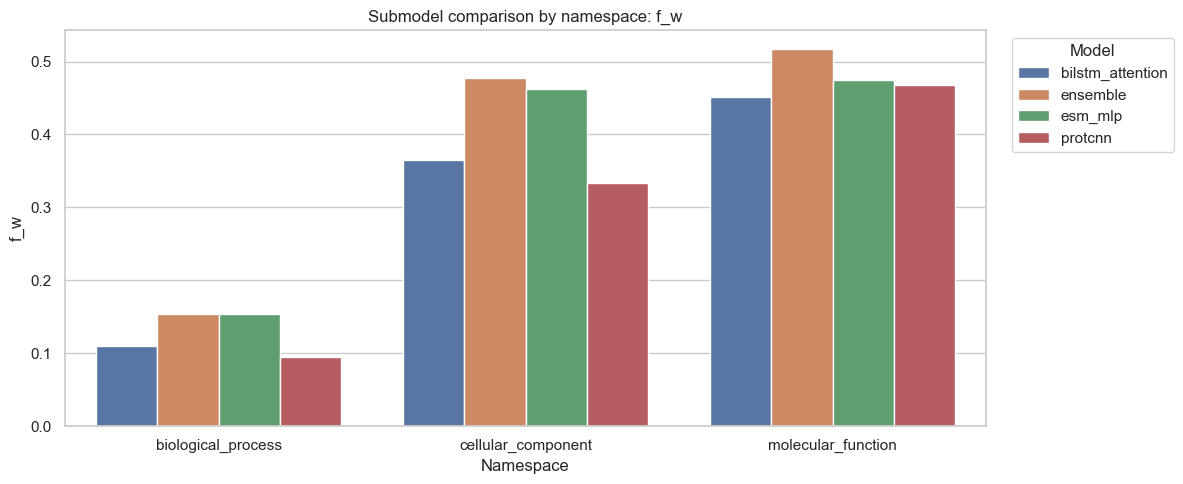

In [34]:
# =============================
# 4. Submodel comparison table on preferred metric
# =============================
preferred = fw_col or f_col or f_micro_w_col or f_micro_col
if preferred is None:
    raise ValueError("No preferred F metric found")

sub = best_by_metric(eval_all[eval_all["_result_set"] == "submodels"], preferred, True)
cols = []
for c in ["_method", "_namespace", "_threshold", preferred, f_col, fw_col, f_micro_col, f_micro_w_col, s_col]:
    if c and c in sub.columns and c not in cols:
        cols.append(c)
sub_compact = sub[cols].sort_values(["_namespace", preferred], ascending=[True, False])
print(f"Preferred metric: {preferred}")
display(sub_compact)

plt.figure(figsize=(12, 5))
sns.barplot(data=sub, x="_namespace", y=preferred, hue="_method")
plt.title(f"Submodel comparison by namespace: {preferred}")
plt.xlabel("Namespace")
plt.ylabel(preferred)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

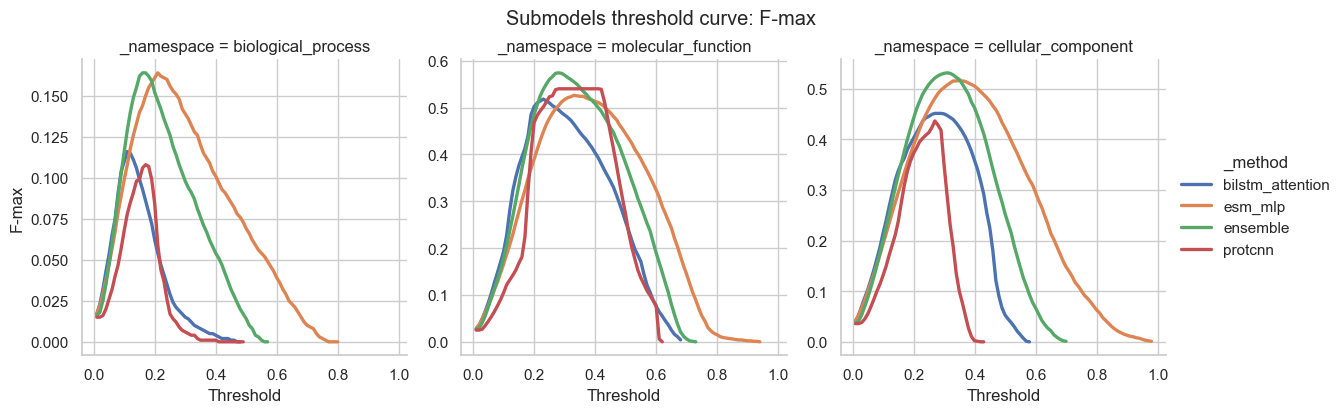

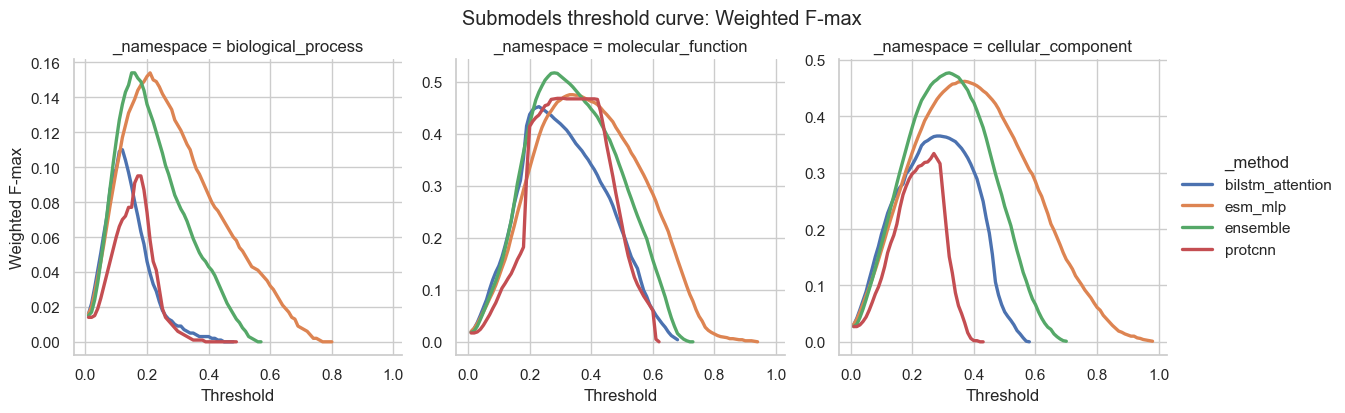

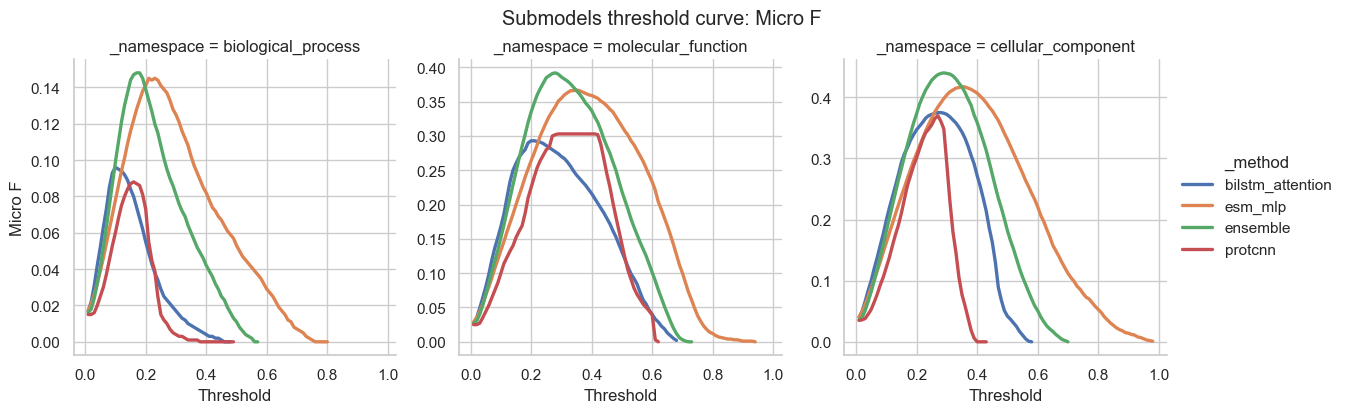

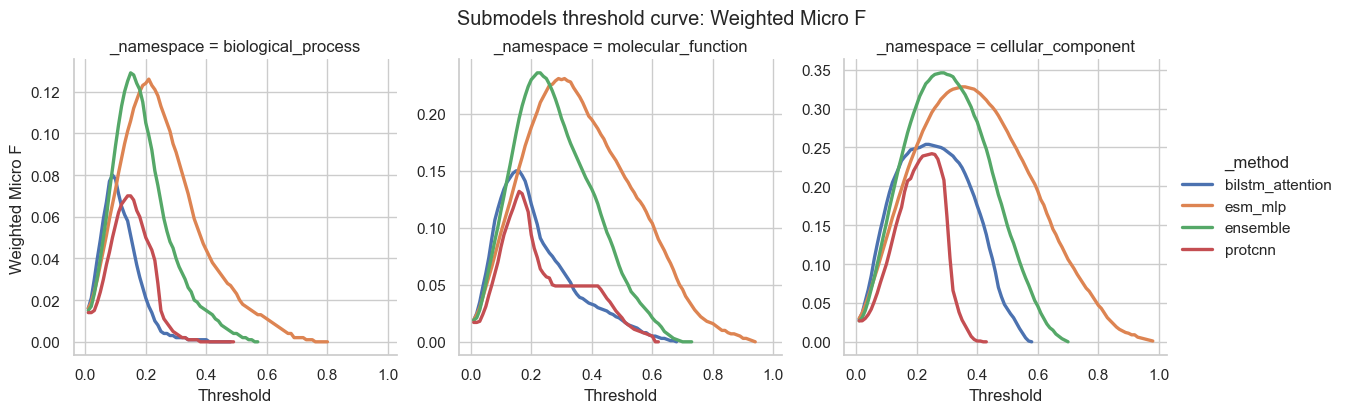

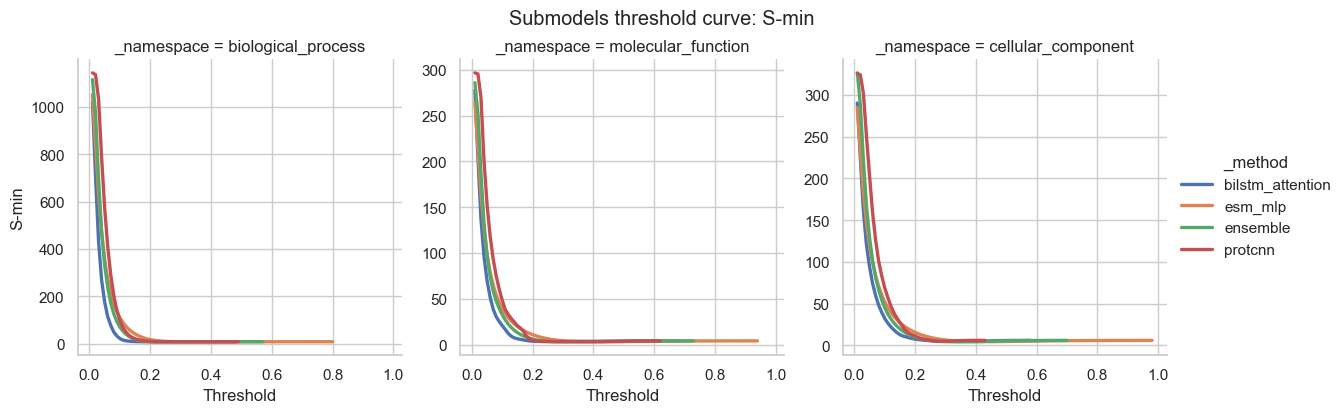

In [35]:
# =============================
# 5. Threshold curves for submodels
# =============================
metrics_to_plot = [
    ("F-max", f_col),
    ("Weighted F-max", fw_col),
    ("Micro F", f_micro_col),
    ("Weighted Micro F", f_micro_w_col),
    ("S-min", s_col),
]
metrics_to_plot = [(name, col) for name, col in metrics_to_plot if col is not None and col in eval_all.columns]
sub_eval = eval_all[eval_all["_result_set"] == "submodels"].copy()

if threshold_col is None:
    print("No threshold column found; cannot draw threshold curves.")
else:
    for name, col in metrics_to_plot:
        g = sns.relplot(
            data=sub_eval.dropna(subset=["_threshold", col]),
            x="_threshold",
            y=col,
            hue="_method",
            col="_namespace",
            kind="line",
            marker=None,
            linewidth=2.4,
            col_wrap=3,
            height=4,
            facet_kws={"sharey": False},
        )
        g.fig.suptitle(f"Submodels threshold curve: {name}", y=1.03)
        g.set_axis_labels("Threshold", name)
        plt.show()

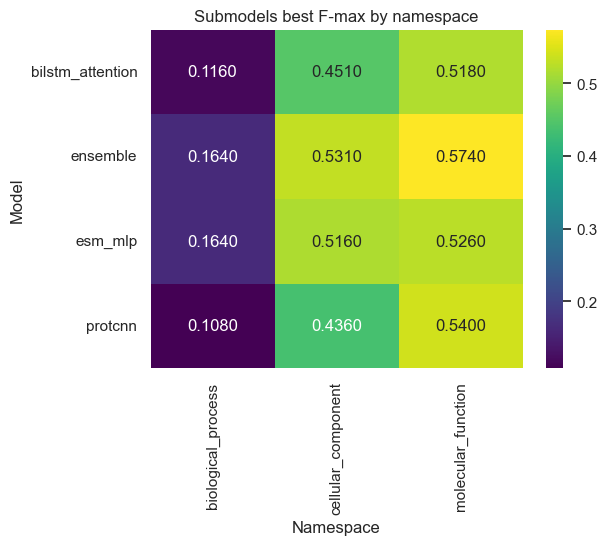

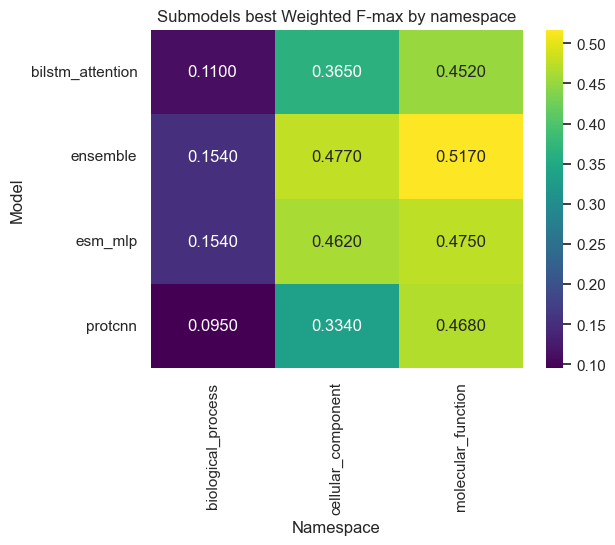

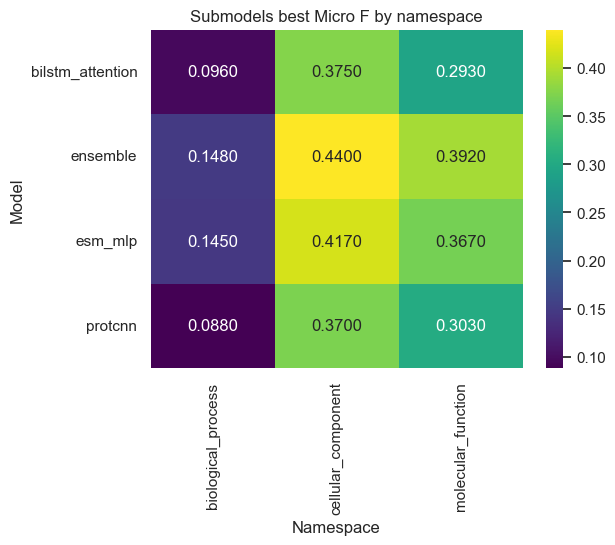

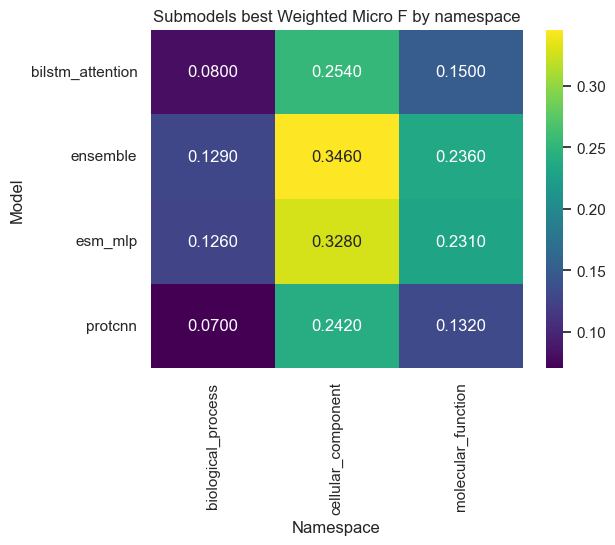

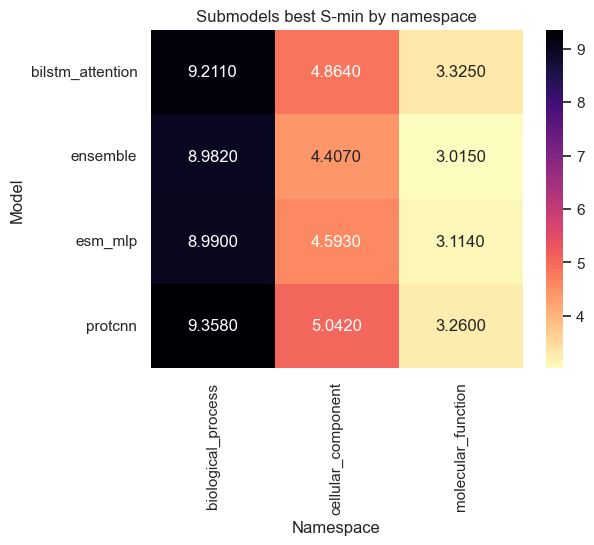

In [36]:
# =============================
# 6. Heatmaps for submodels
# =============================
for name, metric_col, higher in [
    ("F-max", f_col, True),
    ("Weighted F-max", fw_col, True),
    ("Micro F", f_micro_col, True),
    ("Weighted Micro F", f_micro_w_col, True),
    ("S-min", s_col, False),
]:
    if metric_col is None or metric_col not in sub_eval.columns:
        continue
    tmp = best_by_metric(sub_eval, metric_col, higher)
    if not len(tmp):
        continue
    pivot = tmp.pivot_table(index="_method", columns="_namespace", values=metric_col, aggfunc="max" if higher else "min")
    plt.figure(figsize=(max(6, 1.4 * pivot.shape[1]), max(3, 0.6 * pivot.shape[0] + 2)))
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis" if higher else "magma_r")
    plt.title(f"Submodels best {name} by namespace")
    plt.xlabel("Namespace")
    plt.ylabel("Model")
    plt.show()

,_result_set,_method,_namespace,_threshold,f_w,f,f_micro,f_micro_w,s
0,ensemble_original,ensemble,biological_process,0.15,0.154,0.162,0.144,0.129,19.714
3,submodels,ensemble,biological_process,0.15,0.154,0.162,0.144,0.129,19.714
1,ensemble_original,ensemble,cellular_component,0.32,0.477,0.530,0.435,0.341,4.454
4,submodels,ensemble,cellular_component,0.32,0.477,0.530,0.435,0.341,4.454
2,ensemble_original,ensemble,molecular_function,0.28,0.517,0.574,0.392,0.213,3.109
5,submodels,ensemble,molecular_function,0.28,0.517,0.574,0.392,0.213,3.109


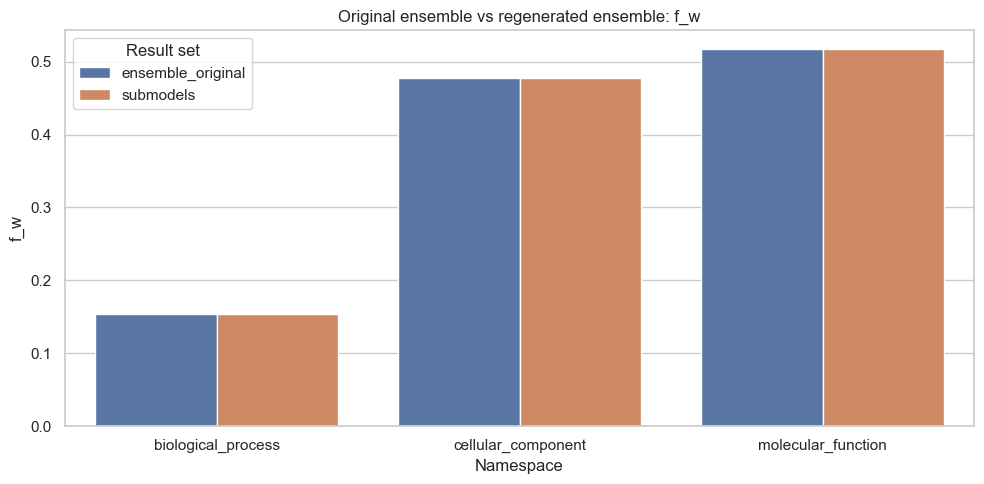

In [37]:
# =============================
# 7. Original ensemble vs regenerated ensemble
# =============================
orig = best_by_metric(eval_all[eval_all["_result_set"] == "ensemble_original"], preferred, True)
regen = best_by_metric(eval_all[(eval_all["_result_set"] == "submodels") & (eval_all["_method"] == "ensemble")], preferred, True)
compare = pd.concat([orig, regen], ignore_index=True)
cols = []
for c in ["_result_set", "_method", "_namespace", "_threshold", preferred, f_col, fw_col, f_micro_col, f_micro_w_col, s_col]:
    if c and c in compare.columns and c not in cols:
        cols.append(c)
display(compare[cols].sort_values(["_namespace", "_result_set"]))

if len(compare):
    plt.figure(figsize=(10, 5))
    sns.barplot(data=compare, x="_namespace", y=preferred, hue="_result_set")
    plt.title(f"Original ensemble vs regenerated ensemble: {preferred}")
    plt.xlabel("Namespace")
    plt.ylabel(preferred)
    plt.legend(title="Result set")
    plt.tight_layout()
    plt.show()

In [38]:
# =============================
# 8. Final compact ranking
# =============================
rank = best_by_metric(sub_eval, preferred, True)
rank_cols = []
for c in ["_method", "_namespace", "_threshold", preferred, s_col]:
    if c and c in rank.columns and c not in rank_cols:
        rank_cols.append(c)
rank = rank[rank_cols]
rank = rank.sort_values(["_namespace", preferred], ascending=[True, False])
print(f"Ranking by {preferred} (higher is better):")
display(rank)

Ranking by f_w (higher is better):


,_method,_namespace,_threshold,f_w,s
3,ensemble,biological_process,0.15,0.154,19.714
6,esm_mlp,biological_process,0.21,0.154,16.046
0,bilstm_attention,biological_process,0.12,0.110,13.283
9,protcnn,biological_process,0.17,0.095,15.313
4,ensemble,cellular_component,0.32,0.477,4.454
7,esm_mlp,cellular_component,0.37,0.462,4.857
1,bilstm_attention,cellular_component,0.28,0.365,5.174
10,protcnn,cellular_component,0.27,0.334,5.265
5,ensemble,molecular_function,0.28,0.517,3.109
8,esm_mlp,molecular_function,0.33,0.475,3.557


,_method,overall_mean_f_w
1,ensemble,0.382667
2,esm_mlp,0.363667
0,bilstm_attention,0.309000
3,protcnn,0.299000


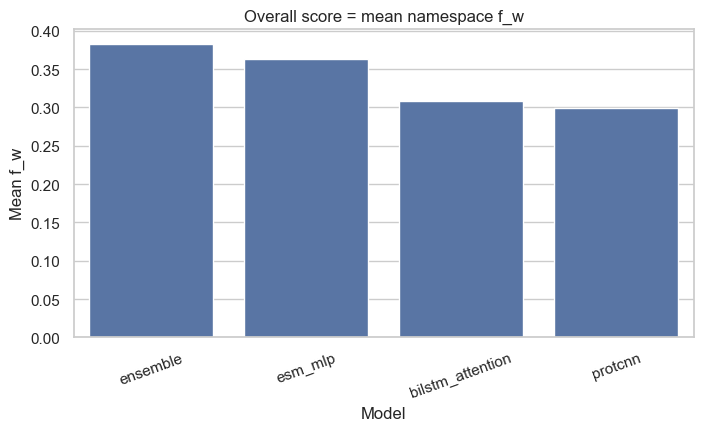

In [ ]:
# Overall score by averaging namespaces
preferred = fw_col or f_col

overall = (
    best_by_metric(sub_eval, preferred, True)
    .groupby("_method")[preferred]
    .mean()
    .reset_index()
    .sort_values(preferred, ascending=False)
)

overall = overall.rename(columns={preferred: f"overall_mean_{preferred}"})
display(overall)

plt.figure(figsize=(8, 4))
sns.barplot(data=overall, x="_method", y=f"overall_mean_{preferred}")
plt.title(f"Overall score = mean namespace {preferred}")
plt.xlabel("Model")
plt.ylabel(f"Mean {preferred}")
plt.xticks(rotation=20)
plt.show()